In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importing the Data

In [2]:
# Importing the data
df_demographics = pd.read_csv('Datasets\Train_Demographics.csv')
df_claims = pd.read_csv('Datasets\Train_Claim.csv')
df_policy = pd.read_csv('Datasets\Train_Policy.csv')
df_vehicle = pd.read_csv('Datasets\Train_Vehicle.csv')
df_target = pd.read_csv('Datasets\Traindata_with_Target.csv')

list_df = [df_demographics, df_claims, df_policy, df_vehicle, df_target]
for df in list_df:
    print(f'{df.shape}')

(28836, 10)
(28836, 19)
(28836, 10)
(115344, 3)
(28836, 2)


# Unpivoting df_vehicle

In [3]:
# Unpivoting df_vehicle to show features in columns
df_vehicle.head(2)

,CustomerID,VehicleAttribute,VehicleAttributeDetails
0,Cust20179,VehicleID,Vehicle8898
1,Cust21384,VehicleModel,Malibu


In [4]:
df_vehicle = df_vehicle.pivot(index = 'CustomerID', columns='VehicleAttribute', values='VehicleAttributeDetails')
print(df_vehicle.shape)
df_vehicle.head(2)

(28836, 4)


VehicleAttribute,VehicleID,VehicleMake,VehicleModel,VehicleYOM
CustomerID,,,,
Cust10000,Vehicle26917,Audi,A5,2008
Cust10001,Vehicle15893,Audi,A5,2006


# Checking datasets for nulls / missing values

In [5]:
# Checking df_demographics
#print(df_demographics.value_counts())
print(df_demographics.isnull().sum())

CustomerID                0
InsuredAge                0
InsuredZipCode            0
InsuredGender            30
InsuredEducationLevel     0
InsuredOccupation         0
InsuredHobbies            0
CapitalGains              0
CapitalLoss               0
Country                   2
dtype: int64


In [6]:
# Checking df_claims
print(df_claims.isnull().sum())
for field in ['PropertyDamage', 'Witnesses', 'PoliceReport', 'TypeOfCollission']:
    print(f'Unique Values for: {field}')
    print(df_claims[field].value_counts())

CustomerID               0
DateOfIncident           0
TypeOfIncident           0
TypeOfCollission         0
SeverityOfIncident       0
AuthoritiesContacted     0
IncidentState            0
IncidentCity             0
IncidentAddress          0
IncidentTime             0
NumberOfVehicles         0
PropertyDamage           0
BodilyInjuries           0
Witnesses                0
PoliceReport             0
AmountOfTotalClaim       0
AmountOfInjuryClaim      0
AmountOfPropertyClaim    0
AmountOfVehicleDamage    0
dtype: int64
Unique Values for: PropertyDamage
?      10459
NO      9687
YES     8690
Name: PropertyDamage, dtype: int64
Unique Values for: Witnesses
2               8449
1               8345
0               6128
3               5868
MISSINGVALUE      46
Name: Witnesses, dtype: int64
Unique Values for: PoliceReport
NO     9898
?      9805
YES    9133
Name: PoliceReport, dtype: int64
Unique Values for: TypeOfCollission
Rear Collision     8561
Side Collision     7867
Front Collision  

In [7]:
# Replacing df_claims missing values with NaN
print(df_claims.shape)
df_claims['PropertyDamage'].replace('?', np.NaN, inplace=True)
df_claims['Witnesses'].replace('MISSINGVALUE', np.NaN, inplace=True)
df_claims['PoliceReport'].replace('?', np.NaN, inplace=True)
df_claims['TypeOfCollission'].replace('?', np.NaN, inplace=True)
print(df_claims.shape)

(28836, 19)
(28836, 19)


In [8]:
# Checking df_policy
print(df_policy.isnull().sum())

InsurancePolicyNumber         0
CustomerLoyaltyPeriod         0
DateOfPolicyCoverage          0
InsurancePolicyState          0
Policy_CombinedSingleLimit    0
Policy_Deductible             0
PolicyAnnualPremium           0
UmbrellaLimit                 0
InsuredRelationship           0
CustomerID                    0
dtype: int64


In [9]:
# Checking df_vehicle
print(df_vehicle.isnull().sum())
for col in df_vehicle.columns:
    print('\n')
    print(f'Checking column: {col}')
    print(df_vehicle[col].value_counts())
    print(df_vehicle[col].value_counts().size)

VehicleAttribute
VehicleID       0
VehicleMake     0
VehicleModel    0
VehicleYOM      0
dtype: int64


Checking column: VehicleID
Vehicle26917    1
Vehicle25995    1
Vehicle7056     1
Vehicle37761    1
Vehicle16919    1
               ..
Vehicle39246    1
Vehicle2737     1
Vehicle19920    1
Vehicle19773    1
Vehicle39163    1
Name: VehicleID, Length: 28836, dtype: int64
28836


Checking column: VehicleMake
Saab          2415
Suburu        2313
Nissan        2300
Dodge         2263
Chevrolet     2174
Ford          2158
Accura        2099
BMW           2073
Toyota        1981
Volkswagen    1960
Audi          1952
Jeep          1946
Mercedes      1659
Honda         1493
???             50
Name: VehicleMake, dtype: int64
15


Checking column: VehicleModel
RAM               1344
Wrangler          1261
A3                1102
MDX               1054
Jetta             1037
Neon               928
Pathfinder         919
Passat             888
Legacy             887
92x                859
Malibu 

In [10]:
# Replacing missing values with NaN
df_vehicle['VehicleMake'].replace('???', np.NaN, inplace=True)

In [11]:
# Checking df_targets
print(df_target.isnull().sum())

CustomerID       0
ReportedFraud    0
dtype: int64


In [12]:
for col in df_target.columns: 
    print(df_target[col].value_counts().size)

28836
2


# Joining the tables together to produce one dataset

In [13]:
datasets = [df_demographics, df_claims, df_policy, df_vehicle, df_target]
for dataset in datasets:
    if dataset.index.name != 'CustomerID':
        dataset.set_index('CustomerID', inplace=True)
        print(dataset.index.name)

CustomerID
CustomerID
CustomerID
CustomerID


In [14]:
df_joined = df_demographics.join(datasets[1:], how='outer')
print(df_joined.shape)
df_joined.head(2)

(28836, 41)


,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,Country,DateOfIncident,...,Policy_CombinedSingleLimit,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleID,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud
CustomerID,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,454776,MALE,JD,armed-forces,movies,56700,-48500,India,2015-02-03,...,100/300,1000,1632.73,0,not-in-family,Vehicle26917,Audi,A5,2008,N
Cust10001,36,454776,MALE,JD,tech-support,cross-fit,70600,-48500,India,2015-02-02,...,100/300,1000,1255.19,0,not-in-family,Vehicle15893,Audi,A5,2006,N


In [15]:
df_joined.isnull().sum()

InsuredAge                        0
InsuredZipCode                    0
InsuredGender                    30
InsuredEducationLevel             0
InsuredOccupation                 0
InsuredHobbies                    0
CapitalGains                      0
CapitalLoss                       0
Country                           2
DateOfIncident                    0
TypeOfIncident                    0
TypeOfCollission               5162
SeverityOfIncident                0
AuthoritiesContacted              0
IncidentState                     0
IncidentCity                      0
IncidentAddress                   0
IncidentTime                      0
NumberOfVehicles                  0
PropertyDamage                10459
BodilyInjuries                    0
Witnesses                        46
PoliceReport                   9805
AmountOfTotalClaim                0
AmountOfInjuryClaim               0
AmountOfPropertyClaim             0
AmountOfVehicleDamage             0
InsurancePolicyNumber       

# Managing Missing Values

## Dropping columns / datapoints that obviously reasonable to drop

In [16]:
# Because "Country" only has one value ("India"), we can reasonably assume
# that the 2 missing values are also = "India", and therefore we can drop
# the column entirely
df_joined.drop(columns='Country', inplace=True)

In [17]:
# Because we are only missing 2 of ~29k datapoints (~0.1%), we can
# reasonably drop these two datapoints without affecting the overall
# dataset / analysis
df_joined.dropna(subset='InsuredGender', inplace=True)
print(df_joined.isnull().sum())
print(df_joined.shape)

InsuredAge                        0
InsuredZipCode                    0
InsuredGender                     0
InsuredEducationLevel             0
InsuredOccupation                 0
InsuredHobbies                    0
CapitalGains                      0
CapitalLoss                       0
DateOfIncident                    0
TypeOfIncident                    0
TypeOfCollission               5158
SeverityOfIncident                0
AuthoritiesContacted              0
IncidentState                     0
IncidentCity                      0
IncidentAddress                   0
IncidentTime                      0
NumberOfVehicles                  0
PropertyDamage                10450
BodilyInjuries                    0
Witnesses                        46
PoliceReport                   9795
AmountOfTotalClaim                0
AmountOfInjuryClaim               0
AmountOfPropertyClaim             0
AmountOfVehicleDamage             0
InsurancePolicyNumber             0
CustomerLoyaltyPeriod       

### Sizing our Reported Fraud problem and seeing if our missing values correlate to fraud

In [18]:
print(df_joined['ReportedFraud'].value_counts())

N    21026
Y     7780
Name: ReportedFraud, dtype: int64


In [19]:
# Because the count of NaN of the 'Witnesses' and 'VehicleMake' fields
# are materially smaller than the Reported Fraud problem, it is also
# reasonable to remove datapoints with these null values
df_joined.dropna(subset=['Witnesses', 'VehicleMake'], inplace=True)
print(df_joined.isnull().sum())
print(df_joined.shape)
pd.set_option('display.max_columns', None)
df_joined.head()

InsuredAge                        0
InsuredZipCode                    0
InsuredGender                     0
InsuredEducationLevel             0
InsuredOccupation                 0
InsuredHobbies                    0
CapitalGains                      0
CapitalLoss                       0
DateOfIncident                    0
TypeOfIncident                    0
TypeOfCollission               5139
SeverityOfIncident                0
AuthoritiesContacted              0
IncidentState                     0
IncidentCity                      0
IncidentAddress                   0
IncidentTime                      0
NumberOfVehicles                  0
PropertyDamage                10414
BodilyInjuries                    0
Witnesses                         0
PoliceReport                   9767
AmountOfTotalClaim                0
AmountOfInjuryClaim               0
AmountOfPropertyClaim             0
AmountOfVehicleDamage             0
InsurancePolicyNumber             0
CustomerLoyaltyPeriod       

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,DateOfIncident,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentState,IncidentCity,IncidentAddress,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,AmountOfInjuryClaim,AmountOfPropertyClaim,AmountOfVehicleDamage,InsurancePolicyNumber,CustomerLoyaltyPeriod,DateOfPolicyCoverage,InsurancePolicyState,Policy_CombinedSingleLimit,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleID,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,454776,MALE,JD,armed-forces,movies,56700,-48500,2015-02-03,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City1,Location 1311,17,3,NaN,1,0,NaN,65501,13417,6071,46013,119121,49,1998-10-25,State1,100/300,1000,1632.73,0,not-in-family,Vehicle26917,Audi,A5,2008,N
Cust10001,36,454776,MALE,JD,tech-support,cross-fit,70600,-48500,2015-02-02,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City5,Location 1311,10,3,YES,2,1,YES,61382,15560,5919,39903,119122,114,2000-11-15,State1,100/300,1000,1255.19,0,not-in-family,Vehicle15893,Audi,A5,2006,N
Cust10002,33,603260,MALE,JD,armed-forces,polo,66400,-63700,2015-01-15,Single Vehicle Collision,Side Collision,Minor Damage,Other,State8,City6,Location 2081,22,1,YES,2,3,NO,66755,11630,11630,43495,119123,167,2001-02-12,State3,500/1000,617,1373.38,0,wife,Vehicle5152,Volkswagen,Jetta,1999,N
Cust10003,36,474848,MALE,JD,armed-forces,polo,47900,-73400,2015-01-19,Single Vehicle Collision,Side Collision,Minor Damage,Other,State9,City6,Location 2081,22,1,YES,2,3,NO,66243,12003,12003,42237,119124,190,2005-04-11,State2,500/1000,722,1337.60,0,own-child,Vehicle37363,Volkswagen,Jetta,2003,N
Cust10004,29,457942,FEMALE,High School,exec-managerial,dancing,0,-41500,2015-01-09,Single Vehicle Collision,Rear Collision,Minor Damage,Fire,State8,City6,Location 1695,10,1,NO,2,1,YES,53544,8829,7234,37481,119125,115,1996-10-25,State2,100/300,500,1353.73,4279863,unmarried,Vehicle28633,Toyota,CRV,2010,N


After initial data cleaning, we have reduced the total size of the dataset by:
 - 1x Column
 - 126x Rows (28836 - 28710), or 0.4%

In [20]:
df_joined.to_csv('CleanedData.csv')

# Feature Creation

We need to create some features to bring some additional datapoints to light:
- CapitalProfit: This will be defined as CapitalGains + CapitalLoss to determine how valuable the customer is to the business
- Policy_LowerSingleLimit: This will be to separate the "lower" amount from the string value of Policy_CombinedSingleLimit
- Policy_UpperSingleLimit: As above, but for the "higher" amount
    - Once this is done, we can drop Policy_CombinedSingleLimit as we have captured that data in a slightly different form

In [21]:
# Calculating CapitalProfit
df_joined['CapitalProfit'] = df_joined['CapitalGains'] + df_joined['CapitalLoss']

# Splitting up Policy_CombinedSingleLimit into numerical features
df_joined[['Policy_LowerSingleLimit', 'Policy_UpperSingleLimit']] = \
            df_joined['Policy_CombinedSingleLimit'].str.split('/', expand=True)

df_joined.head()

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,DateOfIncident,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentState,IncidentCity,IncidentAddress,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,AmountOfInjuryClaim,AmountOfPropertyClaim,AmountOfVehicleDamage,InsurancePolicyNumber,CustomerLoyaltyPeriod,DateOfPolicyCoverage,InsurancePolicyState,Policy_CombinedSingleLimit,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleID,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,Policy_LowerSingleLimit,Policy_UpperSingleLimit
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,454776,MALE,JD,armed-forces,movies,56700,-48500,2015-02-03,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City1,Location 1311,17,3,NaN,1,0,NaN,65501,13417,6071,46013,119121,49,1998-10-25,State1,100/300,1000,1632.73,0,not-in-family,Vehicle26917,Audi,A5,2008,N,8200,100,300
Cust10001,36,454776,MALE,JD,tech-support,cross-fit,70600,-48500,2015-02-02,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City5,Location 1311,10,3,YES,2,1,YES,61382,15560,5919,39903,119122,114,2000-11-15,State1,100/300,1000,1255.19,0,not-in-family,Vehicle15893,Audi,A5,2006,N,22100,100,300
Cust10002,33,603260,MALE,JD,armed-forces,polo,66400,-63700,2015-01-15,Single Vehicle Collision,Side Collision,Minor Damage,Other,State8,City6,Location 2081,22,1,YES,2,3,NO,66755,11630,11630,43495,119123,167,2001-02-12,State3,500/1000,617,1373.38,0,wife,Vehicle5152,Volkswagen,Jetta,1999,N,2700,500,1000
Cust10003,36,474848,MALE,JD,armed-forces,polo,47900,-73400,2015-01-19,Single Vehicle Collision,Side Collision,Minor Damage,Other,State9,City6,Location 2081,22,1,YES,2,3,NO,66243,12003,12003,42237,119124,190,2005-04-11,State2,500/1000,722,1337.60,0,own-child,Vehicle37363,Volkswagen,Jetta,2003,N,-25500,500,1000
Cust10004,29,457942,FEMALE,High School,exec-managerial,dancing,0,-41500,2015-01-09,Single Vehicle Collision,Rear Collision,Minor Damage,Fire,State8,City6,Location 1695,10,1,NO,2,1,YES,53544,8829,7234,37481,119125,115,1996-10-25,State2,100/300,500,1353.73,4279863,unmarried,Vehicle28633,Toyota,CRV,2010,N,-41500,100,300


# Removing obviously synonymous and redundant data

 - We are probably not interested in the exact address of the incident, and we if know the City, we will also know the State, so we can drop both IncidentState and IncidentAddress
 
 - We also know that VehicleID - a unique identifier for each vehicle and not a predictor or driver of fraud - can be dropped
 - AmountOfTotalClaim will also be made up of the sum of its components (AmountOfInjuryClaim, AmountOfPropertyClaim, AmountOfVehicleDamage), so we can drop its component attributes - we can revisit this if we do not achieve our desired error rate

In [22]:
# Creating a new dataframe to avoid overwriting the original dataset

df = df_joined.copy(deep=True) # deep copy to prevent pointing to the object
df = df.drop(columns=['IncidentState', 'IncidentAddress', 'VehicleID', 'AmountOfInjuryClaim', 'AmountOfPropertyClaim',
                     'AmountOfVehicleDamage', 'Policy_CombinedSingleLimit'])
print(list(df.columns))

['InsuredAge', 'InsuredZipCode', 'InsuredGender', 'InsuredEducationLevel', 'InsuredOccupation', 'InsuredHobbies', 'CapitalGains', 'CapitalLoss', 'DateOfIncident', 'TypeOfIncident', 'TypeOfCollission', 'SeverityOfIncident', 'AuthoritiesContacted', 'IncidentCity', 'IncidentTime', 'NumberOfVehicles', 'PropertyDamage', 'BodilyInjuries', 'Witnesses', 'PoliceReport', 'AmountOfTotalClaim', 'InsurancePolicyNumber', 'CustomerLoyaltyPeriod', 'DateOfPolicyCoverage', 'InsurancePolicyState', 'Policy_Deductible', 'PolicyAnnualPremium', 'UmbrellaLimit', 'InsuredRelationship', 'VehicleMake', 'VehicleModel', 'VehicleYOM', 'ReportedFraud', 'CapitalProfit', 'Policy_LowerSingleLimit', 'Policy_UpperSingleLimit']


# Replacing data labels with numerical data
We can One-Hot-Encode most of the categorical data labels, however, the following features must be treated differently due to their nature (nominal and numerical) and the number of distinct values (too many to One Hot Encode without risking overfitting and growing Dimensionality too much):
 - All date fields
 - InsuredZipCode
 - InsurancePolicyNumber

In [23]:
# First lets find out how many values are in each attribute
print('Columns with more than 20 distinct values') # 20 is determined
for col in df.columns:
    cardinality = len(df[col].unique())
    if cardinality > 20: print(f'{col}: {cardinality}')

Columns with more than 20 distinct values
InsuredAge: 46
InsuredZipCode: 995
CapitalGains: 338
CapitalLoss: 354
DateOfIncident: 72
IncidentTime: 24
AmountOfTotalClaim: 21933
InsurancePolicyNumber: 28710
CustomerLoyaltyPeriod: 479
DateOfPolicyCoverage: 6775
Policy_Deductible: 1496
PolicyAnnualPremium: 23762
UmbrellaLimit: 7066
VehicleModel: 39
VehicleYOM: 21
CapitalProfit: 1224


## Dealing with Dates
 - The actual date is not relevant for this analysis, no datapoint in the future (i.e. once the model goes into production) will repeat an historical date
 - We can extract new features from the dates, however:
     - Day of Week: Certain days of week may see more fraudulent claims made
     - TimeToClaim: The time period between the DateOfPolicyCoverage and DateOfIncident
 - Once we extract / create the new date-related features, we can drop the historical dates

In [24]:
df['TimeToClaim'] = pd.to_datetime(df['DateOfIncident']) - pd.to_datetime(df['DateOfPolicyCoverage'])
df['DayOfIncident'] = pd.to_datetime(df['DateOfIncident']).dt.day_of_week

df.drop(columns = ['DateOfIncident', 'DateOfPolicyCoverage'], inplace = True)

## Dealing with ZipCodes
- We first try visualising the ZipCodes to determine if there are ways we can group them together

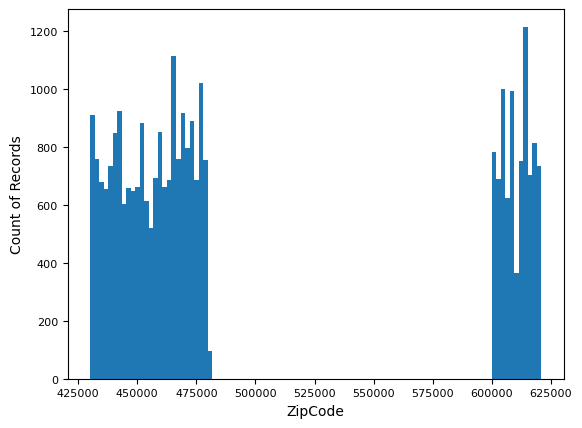

In [25]:
fig, ax = plt.subplots()

ax.hist(df['InsuredZipCode'], bins = 100)
ax.set_xlabel('ZipCode', size=10)
ax.set_ylabel('Count of Records', size=10)
ax.tick_params(axis='both', labelsize=8)
plt.show()

The histogram above shows tell us that:
 - There are distinct groups for ZipCodes
 - We can see two distinct groups:
     1. $~<480,000$
     2. $>= 600,000$
 - We can categorise / binarise these into the groups:
     1. $< 550,000$ - with a value of "0"
     2. $>= 550,000$ - with a value of "1"
     

In [26]:
# Binarizing the zipcodes - we can revisit this if we need the additional level of detail to help with error rate
df['InsuredZipCode'] = pd.DataFrame((df['InsuredZipCode']>=550000)*1)
print(df['InsuredZipCode'].value_counts())

0    20034
1     8676
Name: InsuredZipCode, dtype: int64


## Handling Policy Numbers
 - We need to test whether Policy Numbers are a unique identifier for each customer or if they are some form of classification

In [27]:
print(len(df))
print(len(df['InsurancePolicyNumber'].unique()))

28710
28710


Because this appears to be a unique identifier for each customer, and we already have used CustomerID as an index, we can drop this field

In [28]:
df.drop(columns='InsurancePolicyNumber', inplace=True)
df.head(2)

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentCity,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,CustomerLoyaltyPeriod,InsurancePolicyState,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,Policy_LowerSingleLimit,Policy_UpperSingleLimit,TimeToClaim,DayOfIncident
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,0,MALE,JD,armed-forces,movies,56700,-48500,Multi-vehicle Collision,Side Collision,Total Loss,Police,City1,17,3,NaN,1,0,NaN,65501,49,State1,1000,1632.73,0,not-in-family,Audi,A5,2008,N,8200,100,300,5945 days,1
Cust10001,36,0,MALE,JD,tech-support,cross-fit,70600,-48500,Multi-vehicle Collision,Side Collision,Total Loss,Police,City5,10,3,YES,2,1,YES,61382,114,State1,1000,1255.19,0,not-in-family,Audi,A5,2006,N,22100,100,300,5192 days,0


# Correlation Matrix

In [29]:
# Using ordinal values to calculate correlation matrix
cols_continuous = ['CapitalGains', 'CapitalLoss', 'IncidentTime', 'NumberOfVehicles'
                  ,'BodilyInjuries', 'Witnesses', 'AmountOfTotalClaim', 'CustomerLoyaltyPeriod'
                  , 'CapitalProfit', 'TimeToClaim', 'DayOfIncident']
cols_other = df.columns[~df.columns.isin(cols_continuous)]
print(cols_other)

Index(['InsuredAge', 'InsuredZipCode', 'InsuredGender',
       'InsuredEducationLevel', 'InsuredOccupation', 'InsuredHobbies',
       'TypeOfIncident', 'TypeOfCollission', 'SeverityOfIncident',
       'AuthoritiesContacted', 'IncidentCity', 'PropertyDamage',
       'PoliceReport', 'InsurancePolicyState', 'Policy_Deductible',
       'PolicyAnnualPremium', 'UmbrellaLimit', 'InsuredRelationship',
       'VehicleMake', 'VehicleModel', 'VehicleYOM', 'ReportedFraud',
       'Policy_LowerSingleLimit', 'Policy_UpperSingleLimit'],
      dtype='object')


In [30]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_enc = OrdinalEncoder()
df_ordinals = df.copy(deep=True)
df_ordinals[cols_other] = ordinal_enc.fit_transform(df_ordinals[cols_other])
df_ordinals.head(2)

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentCity,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,CustomerLoyaltyPeriod,InsurancePolicyState,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,Policy_LowerSingleLimit,Policy_UpperSingleLimit,TimeToClaim,DayOfIncident
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,16.0,0.0,1.0,3.0,1.0,12.0,56700,-48500,0.0,2.0,2.0,4.0,0.0,17,3,NaN,1,0,NaN,65501,49,0.0,500.0,22801.0,34.0,1.0,1.0,5.0,13.0,0.0,8200,0.0,1.0,5945 days,1
Cust10001,17.0,0.0,1.0,3.0,12.0,6.0,70600,-48500,0.0,2.0,2.0,4.0,4.0,10,3,1.0,2,1,1.0,61382,114,0.0,500.0,11510.0,34.0,1.0,1.0,5.0,11.0,0.0,22100,0.0,1.0,5192 days,0


In [31]:
print(len(df_ordinals.columns))
print(df_ordinals.shape)
print(df.shape)

35
(28710, 35)
(28710, 35)


In [32]:
df_ordinals.corr()

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentCity,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,PoliceReport,CustomerLoyaltyPeriod,InsurancePolicyState,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,Policy_LowerSingleLimit,Policy_UpperSingleLimit,DayOfIncident
InsuredAge,1.000000,0.042052,0.071255,0.024769,0.019686,-0.067485,-0.010427,0.017499,-0.011445,-0.076048,-0.048676,0.022528,-0.004522,0.113633,0.021713,-0.015884,-0.027243,-0.039605,0.933182,0.002941,0.050893,0.045730,-0.004467,0.057371,0.010386,0.004987,-0.002883,0.009136,0.005230,0.002143,0.012347,-0.004264
InsuredZipCode,0.042052,1.000000,0.005393,0.007424,-0.031241,0.001586,-0.015405,0.028901,-0.006917,-0.025185,0.014203,0.002563,-0.009315,0.006929,0.018568,-0.003564,0.007951,0.021672,0.037920,-0.003916,0.004577,0.040301,0.026170,-0.009632,-0.000422,-0.001386,-0.016297,0.003194,0.009949,0.005972,0.011549,0.007456
InsuredGender,0.071255,0.005393,1.000000,-0.000467,-0.018329,-0.015579,-0.007893,-0.014063,0.001110,-0.012424,-0.014091,0.035966,0.017843,0.019640,0.016404,0.016903,-0.000512,-0.005307,0.067048,0.008914,-0.001392,0.040768,0.024058,-0.001885,0.011603,0.003344,-0.026482,0.025515,-0.015951,0.003330,0.052857,0.008125
InsuredEducationLevel,0.024769,0.007424,-0.000467,1.000000,-0.003989,0.023647,0.022064,0.015927,0.020471,-0.025348,-0.007055,-0.014156,-0.000935,-0.034107,-0.013258,-0.058867,-0.011937,0.033585,0.025684,-0.014370,0.008329,0.015284,-0.033218,0.003795,0.030846,0.014342,0.037045,0.011451,0.027541,0.021069,-0.032200,0.010147
InsuredOccupation,0.019686,-0.031241,-0.018329,-0.003989,1.000000,-0.000670,0.004035,-0.000754,-0.008969,0.002492,0.002558,0.001330,0.004544,-0.004640,-0.001996,-0.018398,0.000338,-0.030703,0.013062,-0.014695,-0.032411,0.049340,0.016308,-0.017633,0.024257,0.011172,-0.020053,0.006659,0.002363,0.018988,-0.010210,-0.001169
InsuredHobbies,-0.067485,0.001586,-0.015579,0.023647,-0.000670,1.000000,0.038421,-0.017379,0.014211,0.022776,-0.020988,-0.020375,0.019538,0.002333,0.009949,0.022154,0.039600,-0.003467,-0.074118,-0.029570,0.003856,-0.022818,-0.037754,-0.060565,-0.005207,0.019761,-0.011431,-0.032768,0.015068,0.008246,0.025110,0.008163
CapitalGains,-0.010427,-0.015405,-0.007893,0.022064,0.004035,0.038421,1.000000,-0.050097,-0.048419,-0.004004,-0.021997,-0.036824,-0.009020,-0.013096,0.058110,-0.038790,0.055355,0.005726,0.002472,0.057567,0.019524,-0.006747,-0.043663,-0.010647,0.017612,0.027229,0.027702,-0.001856,0.685435,0.006030,-0.012616,-0.010891
CapitalLoss,0.017499,0.028901,-0.014063,0.015927,-0.000754,-0.017379,-0.050097,1.000000,0.008590,0.036602,-0.011333,0.014067,-0.046805,-0.016929,-0.002701,0.016288,-0.029470,-0.027896,0.022613,-0.023652,-0.034812,0.014392,-0.024382,-0.034734,-0.042749,-0.023832,-0.064123,-0.014557,0.692881,-0.039514,0.002996,-0.010859
TypeOfIncident,-0.011445,-0.006917,0.001110,0.020471,-0.008969,0.014211,-0.048419,0.008590,1.000000,-0.086299,0.155985,0.087867,0.026902,-0.174798,-0.815220,0.035986,-0.007648,-0.008768,-0.001619,0.008396,-0.026701,0.051528,0.028717,0.037709,-0.029263,-0.023202,-0.067547,-0.038542,-0.028694,0.023285,-0.016894,-0.004684
TypeOfCollission,-0.076048,-0.025185,-0.012424,-0.025348,0.002492,0.022776,-0.004004,0.036602,-0.086299,1.000000,-0.006612,0.061993,0.009300,0.067347,0.080596,0.002799,-0.000577,0.058740,-0.069858,0.057650,-0.036088,0.021936,0.001333,-0.011671,-0.026627,0.000179,0.000802,-0.006867,0.023931,0.015420,-0.015069,-0.000538


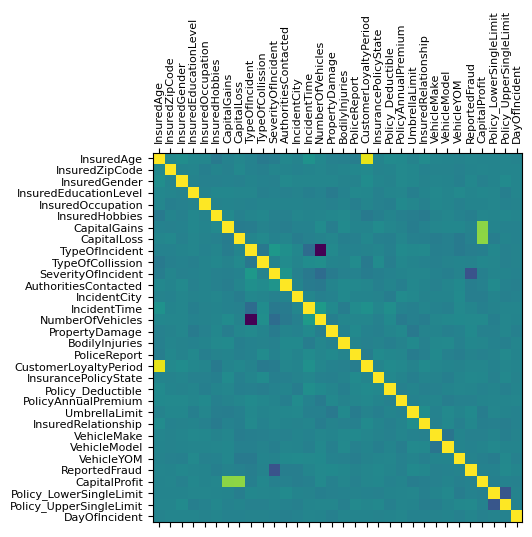

In [33]:
fig, ax = plt.subplots()
df_corr = df_ordinals.corr()
ax.matshow(df_corr)
ax.set_xticks(np.arange(len(df_corr.columns)), labels=df_corr.columns, rotation=90, size=8)
ax.set_yticks(np.arange(len(df_corr.columns)), labels=df_corr.columns, size=8)
plt.show()

# Rescaling non-categorical data
 - We need to rescale the non-categorical data so that the magnitude inherent in the measure does not unfairly weight one feature over another (e.g. CapitalGains vs Witnesses)
 - Doing this first means that we don't need to deal with the prefixes that the OneHotEncoder will create later

In [34]:
df.head(2)

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentCity,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,CustomerLoyaltyPeriod,InsurancePolicyState,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,Policy_LowerSingleLimit,Policy_UpperSingleLimit,TimeToClaim,DayOfIncident
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,0,MALE,JD,armed-forces,movies,56700,-48500,Multi-vehicle Collision,Side Collision,Total Loss,Police,City1,17,3,NaN,1,0,NaN,65501,49,State1,1000,1632.73,0,not-in-family,Audi,A5,2008,N,8200,100,300,5945 days,1
Cust10001,36,0,MALE,JD,tech-support,cross-fit,70600,-48500,Multi-vehicle Collision,Side Collision,Total Loss,Police,City5,10,3,YES,2,1,YES,61382,114,State1,1000,1255.19,0,not-in-family,Audi,A5,2006,N,22100,100,300,5192 days,0


In [35]:
cols_to_rescale = ['InsuredAge', 'CapitalGains', 'CapitalLoss', 'NumberOfVehicles', 'BodilyInjuries', 'Witnesses'
                  , 'AmountOfTotalClaim', 'CustomerLoyaltyPeriod', 'Policy_Deductible', 'PolicyAnnualPremium'
                  , 'UmbrellaLimit', 'CapitalProfit', 'TimeToClaim']
df['TimeToClaim'] = df['TimeToClaim'].dt.days
df[cols_to_rescale].astype('float')

,InsuredAge,CapitalGains,CapitalLoss,NumberOfVehicles,BodilyInjuries,Witnesses,AmountOfTotalClaim,CustomerLoyaltyPeriod,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,CapitalProfit,TimeToClaim
CustomerID,,,,,,,,,,,,,
Cust10000,35.0,56700.0,-48500.0,3.0,1.0,0.0,65501.0,49.0,1000.0,1632.73,0.0,8200.0,5945.0
Cust10001,36.0,70600.0,-48500.0,3.0,2.0,1.0,61382.0,114.0,1000.0,1255.19,0.0,22100.0,5192.0
Cust10002,33.0,66400.0,-63700.0,1.0,2.0,3.0,66755.0,167.0,617.0,1373.38,0.0,2700.0,5085.0
Cust10003,36.0,47900.0,-73400.0,1.0,2.0,3.0,66243.0,190.0,722.0,1337.60,0.0,-25500.0,3570.0
Cust10004,29.0,0.0,-41500.0,1.0,2.0,1.0,53544.0,115.0,500.0,1353.73,4279863.0,-41500.0,6650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cust9993,46.0,0.0,0.0,1.0,0.0,3.0,6590.0,321.0,655.0,1276.01,0.0,0.0,6125.0
Cust9994,44.0,0.0,-28800.0,1.0,0.0,2.0,74547.0,237.0,1089.0,1273.38,0.0,-28800.0,3807.0
Cust9996,53.0,63100.0,-43800.0,1.0,2.0,0.0,55305.0,392.0,787.0,1380.92,3448735.0,19300.0,5984.0


In [36]:
from sklearn.preprocessing import StandardScaler
df[cols_to_rescale] = StandardScaler().fit_transform(df[cols_to_rescale])
df.head()

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentCity,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,CustomerLoyaltyPeriod,InsurancePolicyState,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,Policy_LowerSingleLimit,Policy_UpperSingleLimit,TimeToClaim,DayOfIncident
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,-0.477706,0,MALE,JD,armed-forces,movies,1.216575,-0.843648,Multi-vehicle Collision,Side Collision,Total Loss,Police,City1,17,1.200656,NaN,0.017223,-1.430464,NaN,0.525332,-1.542133,State1,-0.208724,1.690818,-0.499779,not-in-family,Audi,A5,2008,N,0.263255,100,300,0.488754,1
Cust10001,-0.352656,0,MALE,JD,tech-support,cross-fit,1.719455,-0.843648,Multi-vehicle Collision,Side Collision,Total Loss,Police,City5,10,1.200656,YES,1.291651,-0.469592,YES,0.361250,-0.891744,State1,-0.208724,-0.001752,-0.499779,not-in-family,Audi,A5,2006,N,0.626313,100,300,0.174370,0
Cust10002,-0.727805,1,MALE,JD,armed-forces,polo,1.567506,-1.388211,Single Vehicle Collision,Side Collision,Minor Damage,Other,City6,22,-0.839884,YES,1.291651,1.452151,NO,0.575286,-0.361426,State3,-0.909373,0.528112,-0.499779,wife,Volkswagen,Jetta,1999,N,0.119599,500,1000,0.129696,3
Cust10003,-0.352656,0,MALE,JD,armed-forces,polo,0.898205,-1.735729,Single Vehicle Collision,Side Collision,Minor Damage,Other,City6,22,-0.839884,YES,1.291651,1.452151,NO,0.554890,-0.131288,State2,-0.717289,0.367705,-0.499779,own-child,Volkswagen,Jetta,2003,N,-0.616966,500,1000,-0.502830,0
Cust10004,-1.228003,0,FEMALE,High School,exec-managerial,dancing,-0.834742,-0.592863,Single Vehicle Collision,Rear Collision,Minor Damage,Fire,City6,10,-0.839884,NO,1.291651,-0.469592,YES,0.049018,-0.881738,State2,-1.123410,0.440018,1.672221,unmarried,Toyota,CRV,2010,N,-1.034875,100,300,0.783098,4


# Preparing the data labels / replacing strings with numbers
- As the target feature is Y/N, we can binarize this easily
- With the remaining fields, we can use One Hot Encoding to transform the categorical data into something the machine learning models can use (i.e. numpy friendly)

In [37]:
df['ReportedFraud'] = (df['ReportedFraud']=='Y')*1
print(df['ReportedFraud'].value_counts())

0    20959
1     7751
Name: ReportedFraud, dtype: int64


In [38]:
# First lets see how many unique values per column
for col in df.columns:
    print(f'{col}: {len(df[col].value_counts())}') # we use value_counts to exclude Missing Values

InsuredAge: 46
InsuredZipCode: 2
InsuredGender: 2
InsuredEducationLevel: 7
InsuredOccupation: 14
InsuredHobbies: 20
CapitalGains: 338
CapitalLoss: 354
TypeOfIncident: 4
TypeOfCollission: 3
SeverityOfIncident: 4
AuthoritiesContacted: 5
IncidentCity: 7
IncidentTime: 24
NumberOfVehicles: 4
PropertyDamage: 2
BodilyInjuries: 3
Witnesses: 4
PoliceReport: 2
AmountOfTotalClaim: 21933
CustomerLoyaltyPeriod: 479
InsurancePolicyState: 3
Policy_Deductible: 1496
PolicyAnnualPremium: 23762
UmbrellaLimit: 7066
InsuredRelationship: 6
VehicleMake: 14
VehicleModel: 39
VehicleYOM: 21
ReportedFraud: 2
CapitalProfit: 1224
Policy_LowerSingleLimit: 3
Policy_UpperSingleLimit: 3
TimeToClaim: 7349
DayOfIncident: 7


In [39]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

cols_for_ordinalencoder = ['InsuredGender', 'PropertyDamage', 'PoliceReport']
cols_for_onehotencoder = ['InsuredEducationLevel', 'InsuredOccupation', 'InsuredHobbies', 'TypeOfIncident', 
                          'TypeOfCollission', 'SeverityOfIncident', 'AuthoritiesContacted', 'IncidentCity',
                         'InsurancePolicyState', 'InsuredRelationship', 'Policy_LowerSingleLimit',
                          'Policy_UpperSingleLimit', 'DayOfIncident', 'VehicleMake', 'VehicleModel', 'VehicleYOM']

In [40]:
# Creating a copy of df to manipulate
df_numerical = df.copy(deep=True)

In [41]:
# For binary features, we will use the OrdinalEncoder to encode within the column
ordinal_enc = OrdinalEncoder()
df_numerical[cols_for_ordinalencoder] = ordinal_enc.fit_transform(df_numerical[cols_for_ordinalencoder])

# We then replace any missing values (which OrdinalEncoder ignores) with -1
# While technically we have imparted order to this feature, it will allow us to
# keep dimensionality lower
df_numerical[cols_for_ordinalencoder] = df_numerical[cols_for_ordinalencoder].replace(np.NaN, -1)
'''
for col in cols_for_ordinalencoder:
    print(df_numerical[col].value_counts())
'''
df_numerical.head(2)

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentCity,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,CustomerLoyaltyPeriod,InsurancePolicyState,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,Policy_LowerSingleLimit,Policy_UpperSingleLimit,TimeToClaim,DayOfIncident
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,-0.477706,0,1.0,JD,armed-forces,movies,1.216575,-0.843648,Multi-vehicle Collision,Side Collision,Total Loss,Police,City1,17,1.200656,-1.0,0.017223,-1.430464,-1.0,0.525332,-1.542133,State1,-0.208724,1.690818,-0.499779,not-in-family,Audi,A5,2008,0,0.263255,100,300,0.488754,1
Cust10001,-0.352656,0,1.0,JD,tech-support,cross-fit,1.719455,-0.843648,Multi-vehicle Collision,Side Collision,Total Loss,Police,City5,10,1.200656,1.0,1.291651,-0.469592,1.0,0.361250,-0.891744,State1,-0.208724,-0.001752,-0.499779,not-in-family,Audi,A5,2006,0,0.626313,100,300,0.174370,0


In [42]:
# Before we start for non-binary features, we will treat the missing data as another
# point of data; i.e. we don't know if missing-ness correlates with the target, so
# we capture it as a datapoint

df_numerical[cols_for_onehotencoder] = df_numerical[cols_for_onehotencoder].replace(np.NaN, "Missing Data")

print(df_numerical['TypeOfCollission'].value_counts())


Rear Collision     8515
Side Collision     7834
Front Collision    7222
Missing Data       5139
Name: TypeOfCollission, dtype: int64


In [43]:
# For non-binary features we wil use the OneHotEncoder to avoid imparting too much
# order to the feature - this will, however, massively increase our dimensionality

onehot_enc = OneHotEncoder(sparse=False) # Cannot use Sparse matrix as the input matrix is not numerical
column_transformer = make_column_transformer((onehot_enc, cols_for_onehotencoder), remainder='passthrough')
transformed_columns = column_transformer.fit_transform(df_numerical)

df_numerical = pd.DataFrame(transformed_columns, columns=column_transformer.get_feature_names_out())
print(df_numerical.shape)
df_numerical.head(2)

(28710, 180)


,onehotencoder__InsuredEducationLevel_Associate,onehotencoder__InsuredEducationLevel_College,onehotencoder__InsuredEducationLevel_High School,onehotencoder__InsuredEducationLevel_JD,onehotencoder__InsuredEducationLevel_MD,onehotencoder__InsuredEducationLevel_Masters,onehotencoder__InsuredEducationLevel_PhD,onehotencoder__InsuredOccupation_adm-clerical,onehotencoder__InsuredOccupation_armed-forces,onehotencoder__InsuredOccupation_craft-repair,onehotencoder__InsuredOccupation_exec-managerial,onehotencoder__InsuredOccupation_farming-fishing,onehotencoder__InsuredOccupation_handlers-cleaners,onehotencoder__InsuredOccupation_machine-op-inspct,onehotencoder__InsuredOccupation_other-service,onehotencoder__InsuredOccupation_priv-house-serv,onehotencoder__InsuredOccupation_prof-specialty,onehotencoder__InsuredOccupation_protective-serv,onehotencoder__InsuredOccupation_sales,onehotencoder__InsuredOccupation_tech-support,onehotencoder__InsuredOccupation_transport-moving,onehotencoder__InsuredHobbies_base-jumping,onehotencoder__InsuredHobbies_basketball,onehotencoder__InsuredHobbies_board-games,onehotencoder__InsuredHobbies_bungie-jumping,onehotencoder__InsuredHobbies_camping,onehotencoder__InsuredHobbies_chess,onehotencoder__InsuredHobbies_cross-fit,onehotencoder__InsuredHobbies_dancing,onehotencoder__InsuredHobbies_exercise,onehotencoder__InsuredHobbies_golf,onehotencoder__InsuredHobbies_hiking,onehotencoder__InsuredHobbies_kayaking,onehotencoder__InsuredHobbies_movies,onehotencoder__InsuredHobbies_paintball,onehotencoder__InsuredHobbies_polo,onehotencoder__InsuredHobbies_reading,onehotencoder__InsuredHobbies_skydiving,onehotencoder__InsuredHobbies_sleeping,onehotencoder__InsuredHobbies_video-games,onehotencoder__InsuredHobbies_yachting,onehotencoder__TypeOfIncident_Multi-vehicle Collision,onehotencoder__TypeOfIncident_Parked Car,onehotencoder__TypeOfIncident_Single Vehicle Collision,onehotencoder__TypeOfIncident_Vehicle Theft,onehotencoder__TypeOfCollission_Front Collision,onehotencoder__TypeOfCollission_Missing Data,onehotencoder__TypeOfCollission_Rear Collision,onehotencoder__TypeOfCollission_Side Collision,onehotencoder__SeverityOfIncident_Major Damage,onehotencoder__SeverityOfIncident_Minor Damage,onehotencoder__SeverityOfIncident_Total Loss,onehotencoder__SeverityOfIncident_Trivial Damage,onehotencoder__AuthoritiesContacted_Ambulance,onehotencoder__AuthoritiesContacted_Fire,onehotencoder__AuthoritiesContacted_None,onehotencoder__AuthoritiesContacted_Other,onehotencoder__AuthoritiesContacted_Police,onehotencoder__IncidentCity_City1,onehotencoder__IncidentCity_City2,onehotencoder__IncidentCity_City3,onehotencoder__IncidentCity_City4,onehotencoder__IncidentCity_City5,onehotencoder__IncidentCity_City6,onehotencoder__IncidentCity_City7,onehotencoder__InsurancePolicyState_State1,onehotencoder__InsurancePolicyState_State2,onehotencoder__InsurancePolicyState_State3,onehotencoder__InsuredRelationship_husband,onehotencoder__InsuredRelationship_not-in-family,onehotencoder__InsuredRelationship_other-relative,onehotencoder__InsuredRelationship_own-child,onehotencoder__InsuredRelationship_unmarried,onehotencoder__InsuredRelationship_wife,onehotencoder__Policy_LowerSingleLimit_100,onehotencoder__Policy_LowerSingleLimit_250,onehotencoder__Policy_LowerSingleLimit_500,onehotencoder__Policy_UpperSingleLimit_1000,onehotencoder__Policy_UpperSingleLimit_300,onehotencoder__Policy_UpperSingleLimit_500,onehotencoder__DayOfIncident_0,onehotencoder__DayOfIncident_1,onehotencoder__DayOfIncident_2,onehotencoder__DayOfIncident_3,onehotencoder__DayOfIncident_4,onehotencoder__DayOfIncident_5,onehotencoder__DayOfIncident_6,onehotencoder__VehicleMake_Accura,onehotencoder__VehicleMake_Audi,onehotencoder__VehicleMake_BMW,onehotencoder__VehicleMake_Chevrolet,onehotencoder__VehicleMake_Dodge,onehotencoder__VehicleMake_Ford,onehotencoder__VehicleMake_Honda,onehotencoder__VehicleMake_Jeep,onehotencoder__VehicleMake_Mercedes,onehotencoder__VehicleMake_Nissan,onehotencode

In [44]:
print(df_numerical.columns)

Index(['onehotencoder__InsuredEducationLevel_Associate',
       'onehotencoder__InsuredEducationLevel_College',
       'onehotencoder__InsuredEducationLevel_High School',
       'onehotencoder__InsuredEducationLevel_JD',
       'onehotencoder__InsuredEducationLevel_MD',
       'onehotencoder__InsuredEducationLevel_Masters',
       'onehotencoder__InsuredEducationLevel_PhD',
       'onehotencoder__InsuredOccupation_adm-clerical',
       'onehotencoder__InsuredOccupation_armed-forces',
       'onehotencoder__InsuredOccupation_craft-repair',
       ...
       'remainder__Witnesses', 'remainder__PoliceReport',
       'remainder__AmountOfTotalClaim', 'remainder__CustomerLoyaltyPeriod',
       'remainder__Policy_Deductible', 'remainder__PolicyAnnualPremium',
       'remainder__UmbrellaLimit', 'remainder__ReportedFraud',
       'remainder__CapitalProfit', 'remainder__TimeToClaim'],
      dtype='object', length=180)


In [45]:
df_numerical.to_csv('PreprocessedData.csv')

# Fitting to a model
 - We are now ready to fit the dataset to a model
 - We will use two different classification models:
     1. k-Nearest Neighbour
     2. Multi-Layer Perceptron (??)

In [46]:
# First we need to define our X and y
from sklearn.model_selection import train_test_split

X = df_numerical.loc[:, df_numerical.columns!='remainder__ReportedFraud']
y = df_numerical['remainder__ReportedFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, shuffle=True)

print(X_test.shape)
print(y_test.shape)

(9475, 179)
(9475,)


In [47]:
from sklearn.neighbors import KNeighborsClassifier
clf_knn = KNeighborsClassifier(n_neighbors = 7)
clf_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

C:\Users\wesle\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


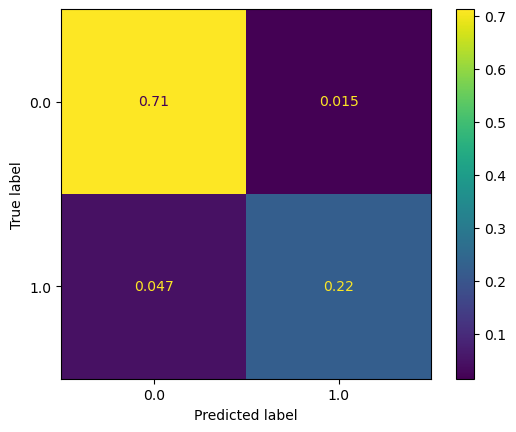

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = clf_knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred, normalize='all')
conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_knn.classes_)
conf_matrix.plot()
plt.show()

In [49]:
# calculating the performance metrics
from sklearn.metrics import precision_recall_fscore_support

precision_recall_fscore_support(y_test, y_pred, pos_label=1, average='binary')

(0.9365918097754293, 0.8260194174757282, 0.8778373916632274, None)

In [50]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(y_test, y_pred)

0.9025749261291685